# Step: 1

## Q1: What is Regression? How is it different from Classification?

- **Regression** predicts a **continuous numerical value** (e.g., price, salary, temperature)
- **Classification** predicts a **discrete category/label** (e.g., spam/not spam, approved/rejected)
- The key difference: regression answers *"how much?"*, classification answers *"which one?"*

**Indian Examples:**
- HDFC Bank predicting the EMI amount for a home loan applicant → Regression
- A farmer in Maharashtra predicting crop yield (tonnes/hectare) based on rainfall and soil → Regression

## Q2: Simple vs Multiple vs Regularised Regression

- **Simple Linear Regression:** One input feature → one output (e.g., price predicted from only area)
- **Multiple Linear Regression:** Many input features → one output (e.g., price from area + location + age + rooms)
- **Ridge (L2):** Adds penalty = sum of squared coefficients → shrinks all coefficients, none become zero
- **Lasso (L1):** Adds penalty = sum of absolute coefficients → shrinks some coefficients **to exactly zero** (automatic feature selection)

## Q3: Overfitting, Underfitting, and Regularisation

- **Overfitting:** Model memorises training data, performs poorly on new data (high variance)
- **Underfitting:** Model is too simple, fails to capture patterns even in training data (high bias)
- **Regularisation** adds a penalty term to the loss function, discouraging the model from assigning large weights to any feature
- **L1 (Lasso)** zeroes out irrelevant features → reduces model complexity
- **L2 (Ridge)** distributes weights evenly → prevents any one feature from dominating

## Q4: RMSE, MAE, and R²

- **MAE (Mean Absolute Error):** Average of absolute differences between actual and predicted — easy to interpret, robust to outliers
- **RMSE (Root Mean Squared Error):** Square root of average squared errors — penalises large errors more heavily than MAE
- **R² (R-squared):** Proportion of variance in target explained by the model — ranges 0 to 1, higher is better

**When to prefer RMSE over MAE:**
- When large prediction errors are especially costly (e.g., underpricing a house by ₹50L is far worse than underpricing by ₹2L)
- RMSE punishes big mistakes harder, making it more suitable for house price prediction

## Q5: Cross-Validation (k-Fold)

- **k-Fold CV** splits data into k equal parts; model trains on k-1 parts and tests on the remaining 1, repeated k times
- Final score = average of all k test scores
- **Why preferred over single train-test split:**
  - Single split result depends heavily on which rows land in test set (luck-based)
  - k-Fold uses every row for both training and testing across rounds → more reliable, less biased estimate
  - Reduces variance in performance evaluation, especially important on small-to-medium datasets like Ames (1460 rows)

# Step: 2

## 2.1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("train.csv")

print("Shape:", df.shape)
print("\n--- INFO ---")
df.info()
print("\n--- DESCRIBE ---")
df.describe()

Shape: (1460, 81)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [2]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("\nColumns with missing values:")
print(missing)

Numerical columns: 38
Categorical columns: 43

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


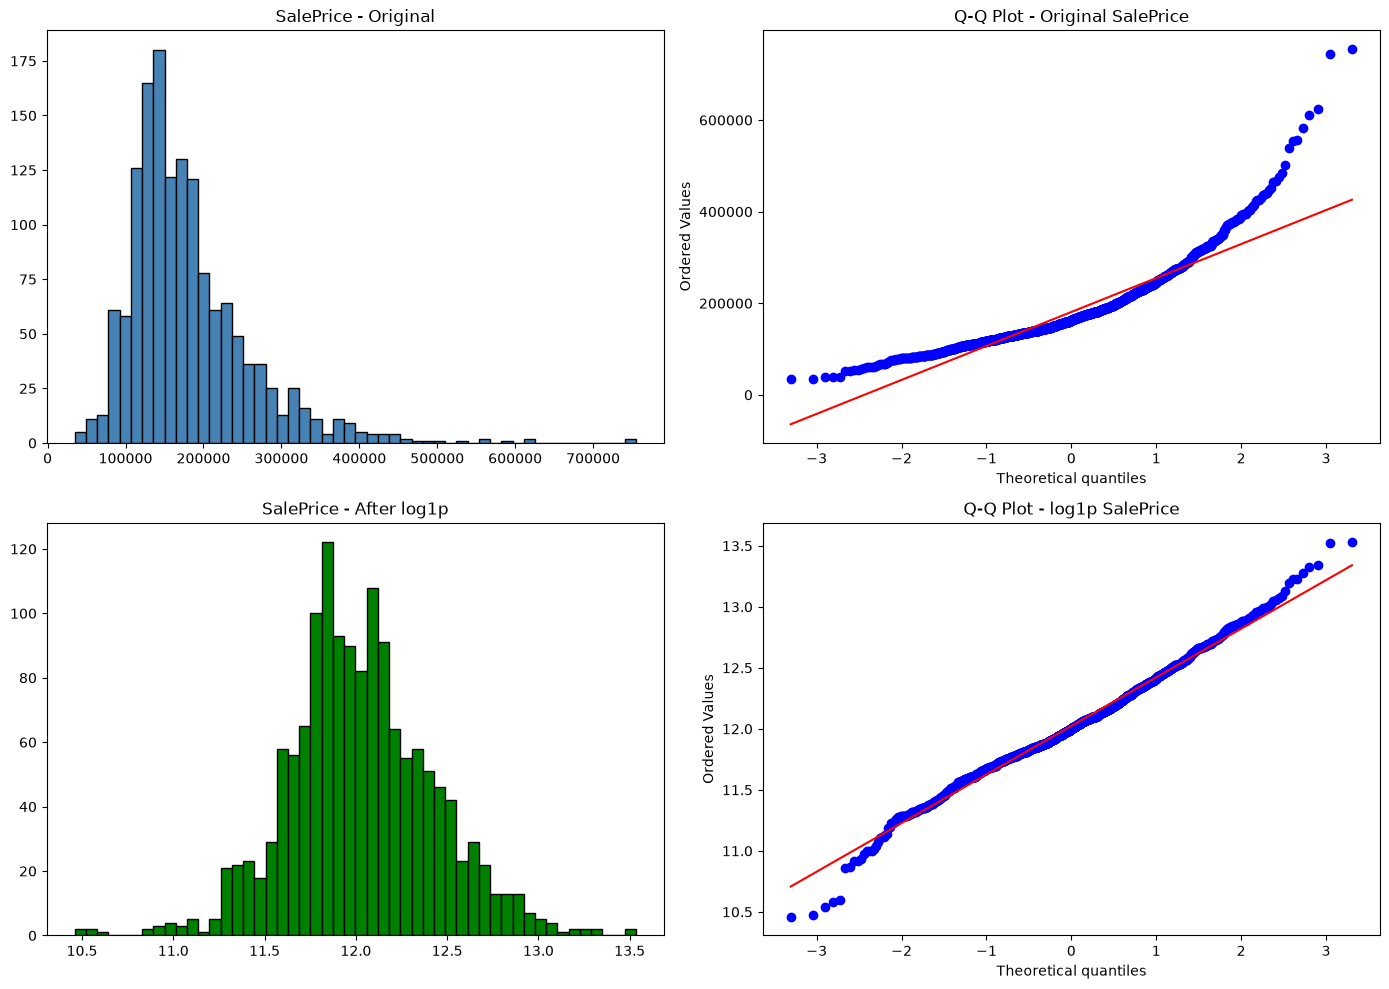

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title("SalePrice - Original")

stats.probplot(df['SalePrice'], plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot - Original SalePrice")

log_price = np.log1p(df['SalePrice'])
axes[1, 0].hist(log_price, bins=50, color='green', edgecolor='black')
axes[1, 0].set_title("SalePrice - After log1p")

stats.probplot(log_price, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot - log1p SalePrice")

plt.tight_layout()
plt.show()

## 2.2

Top 5 Most Skewed Columns:
MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


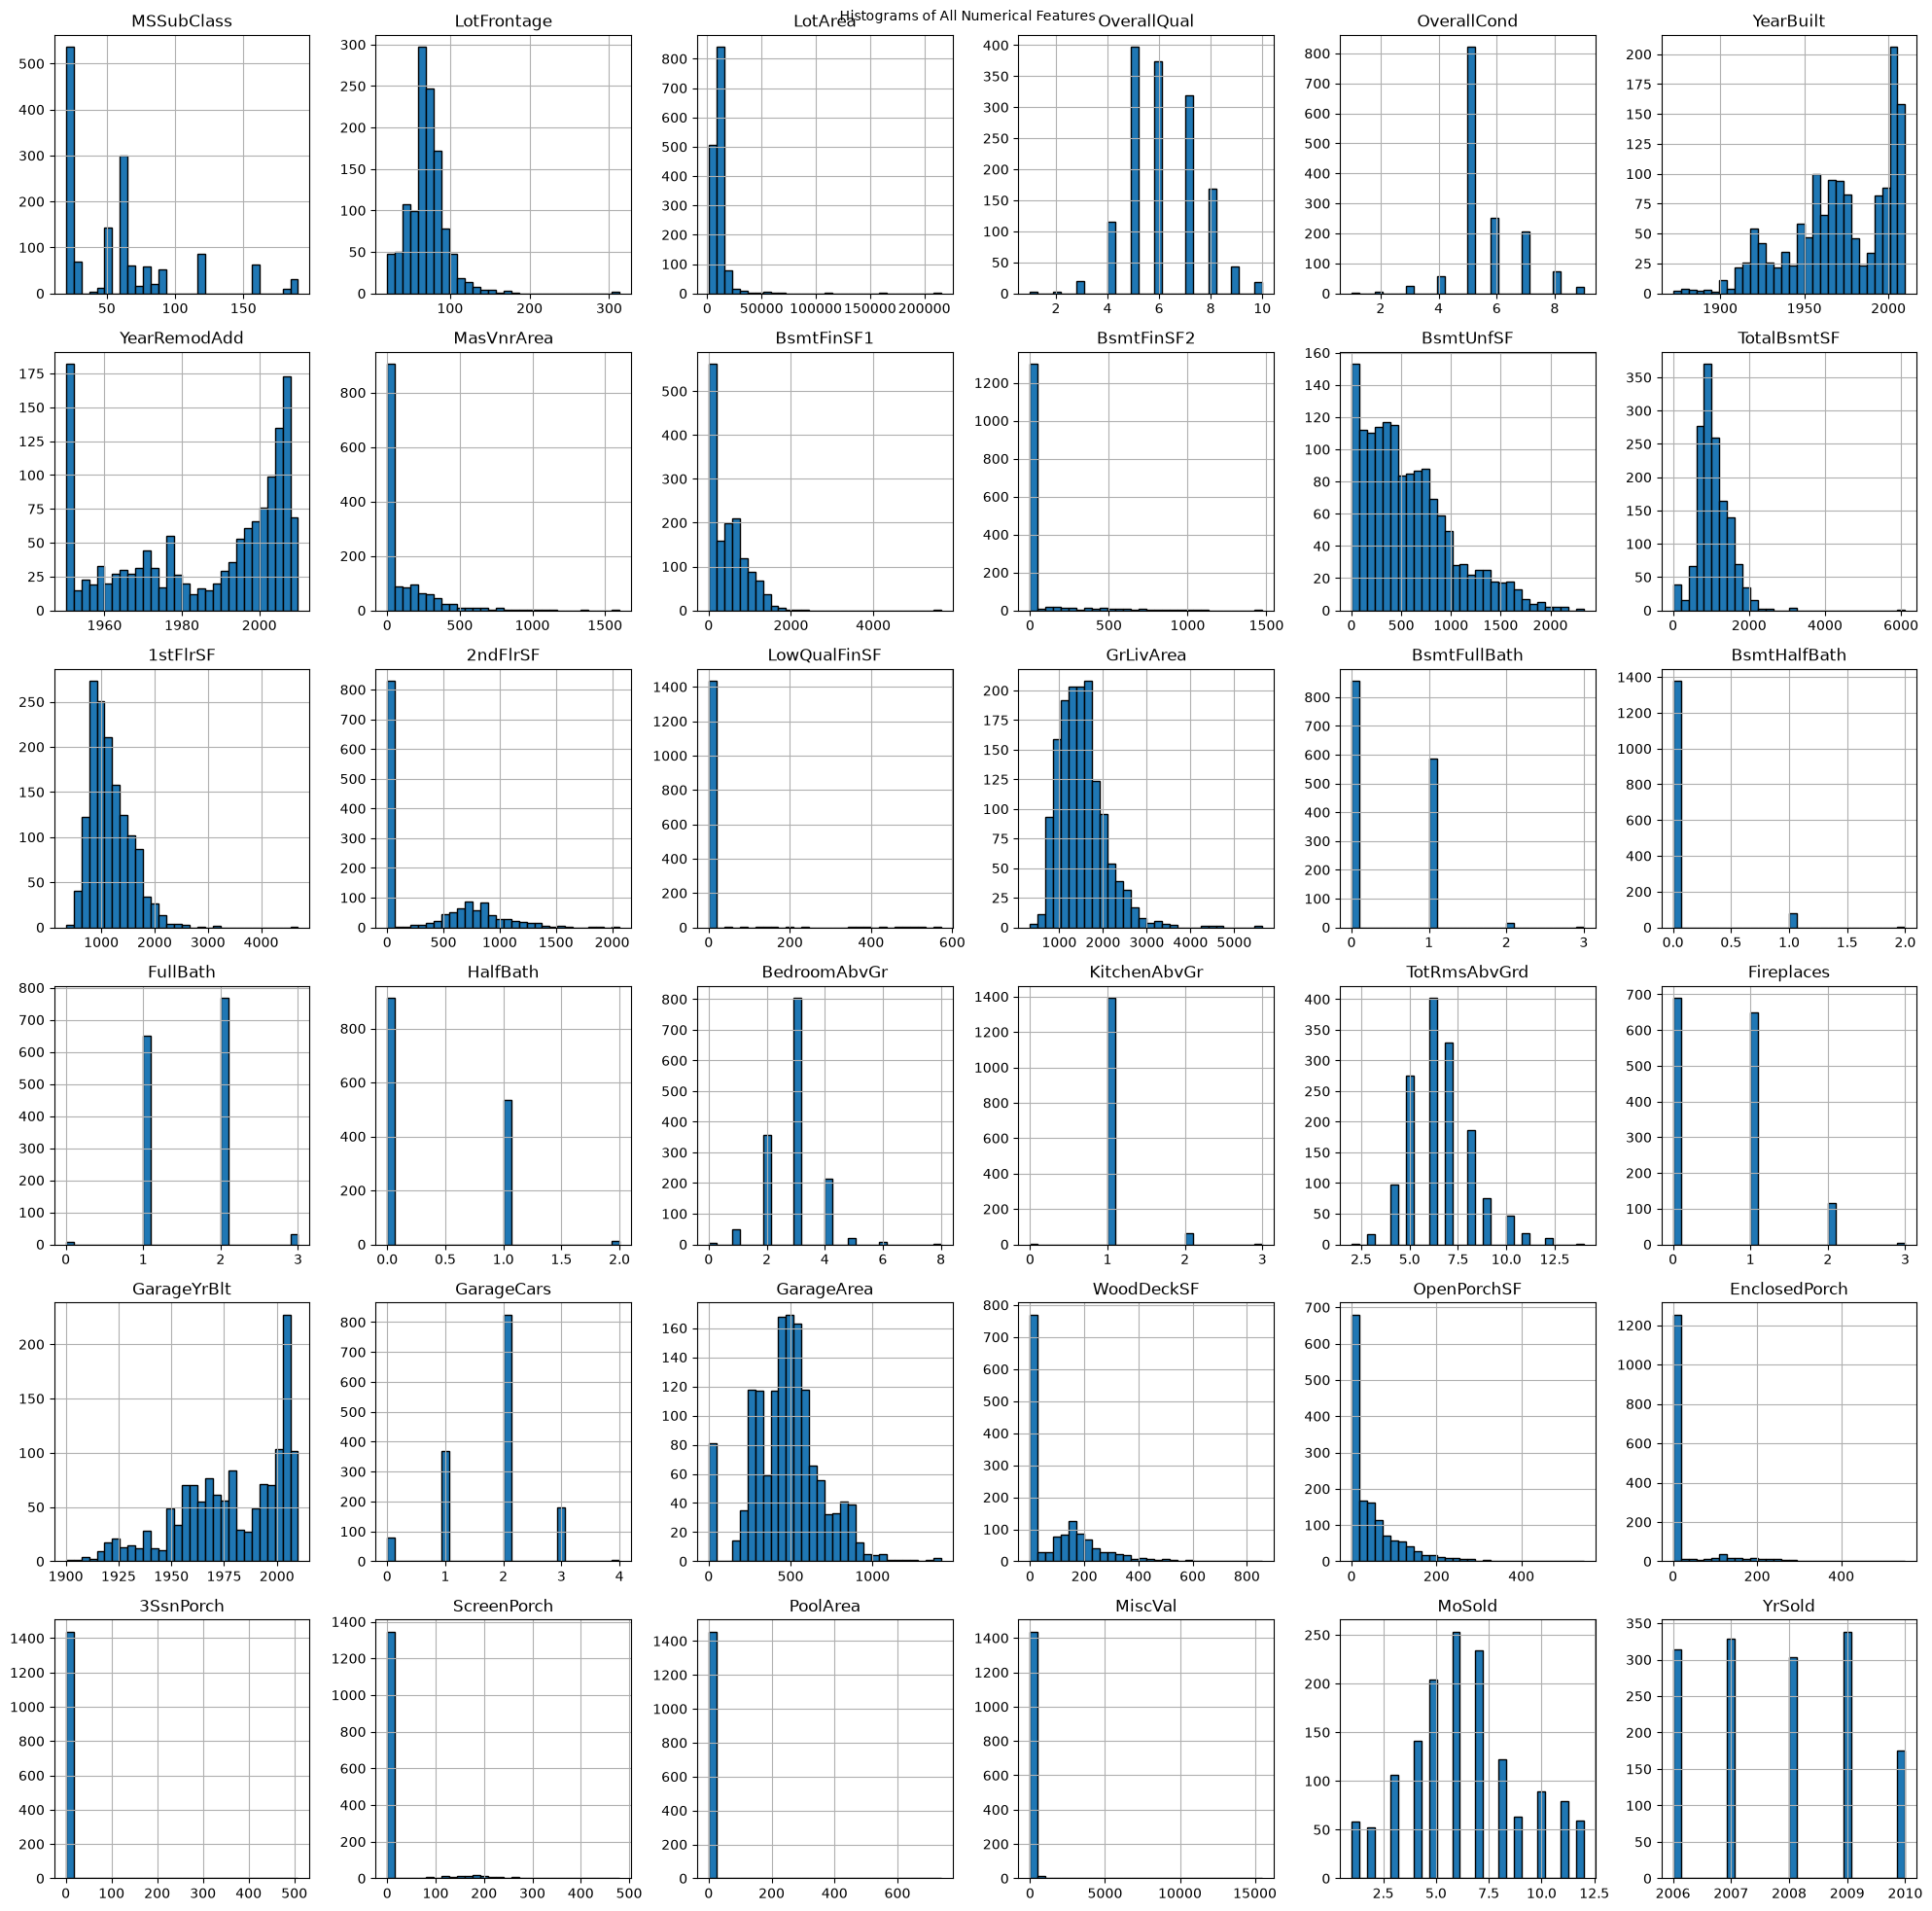

In [5]:
numerical_cols = df.select_dtypes(include=np.number).drop(columns=['Id', 'SalePrice']).columns

skewness = df[numerical_cols].skew().sort_values(ascending=False)
print("Top 5 Most Skewed Columns:")
print(skewness.head())

df[numerical_cols].hist(figsize=(20, 20), bins=30, edgecolor='black')
plt.suptitle("Histograms of All Numerical Features", fontsize=10)
plt.tight_layout()
plt.show()

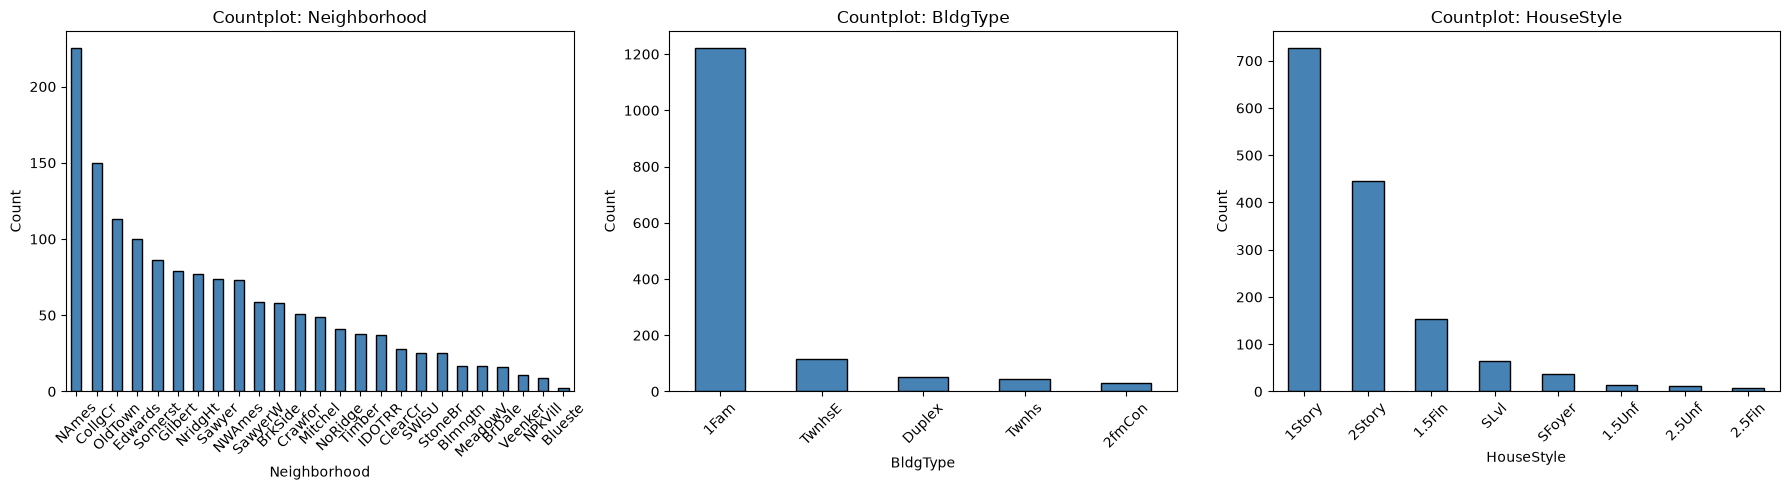

In [6]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Neighborhood', 'BldgType', 'HouseStyle']):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f"Countplot: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2.3

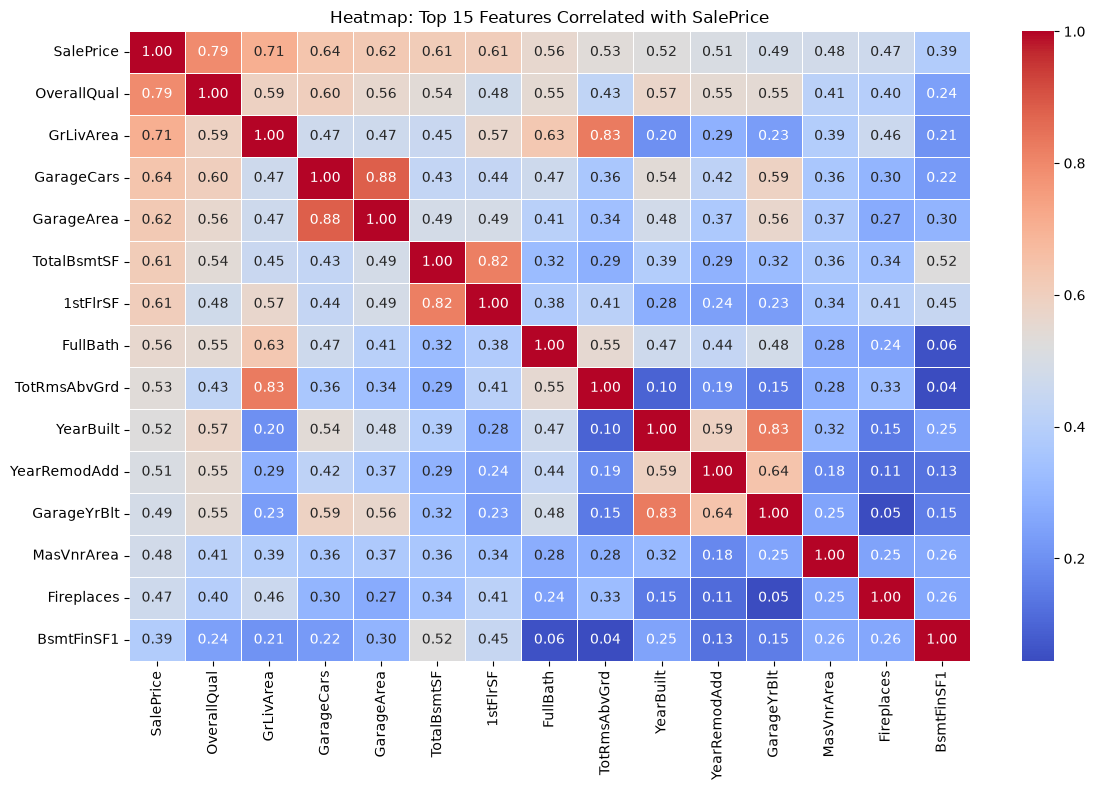

In [7]:
corr = df.select_dtypes(include=np.number).corr()
top15 = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(df[top15].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap: Top 15 Features Correlated with SalePrice")
plt.tight_layout()
plt.show()

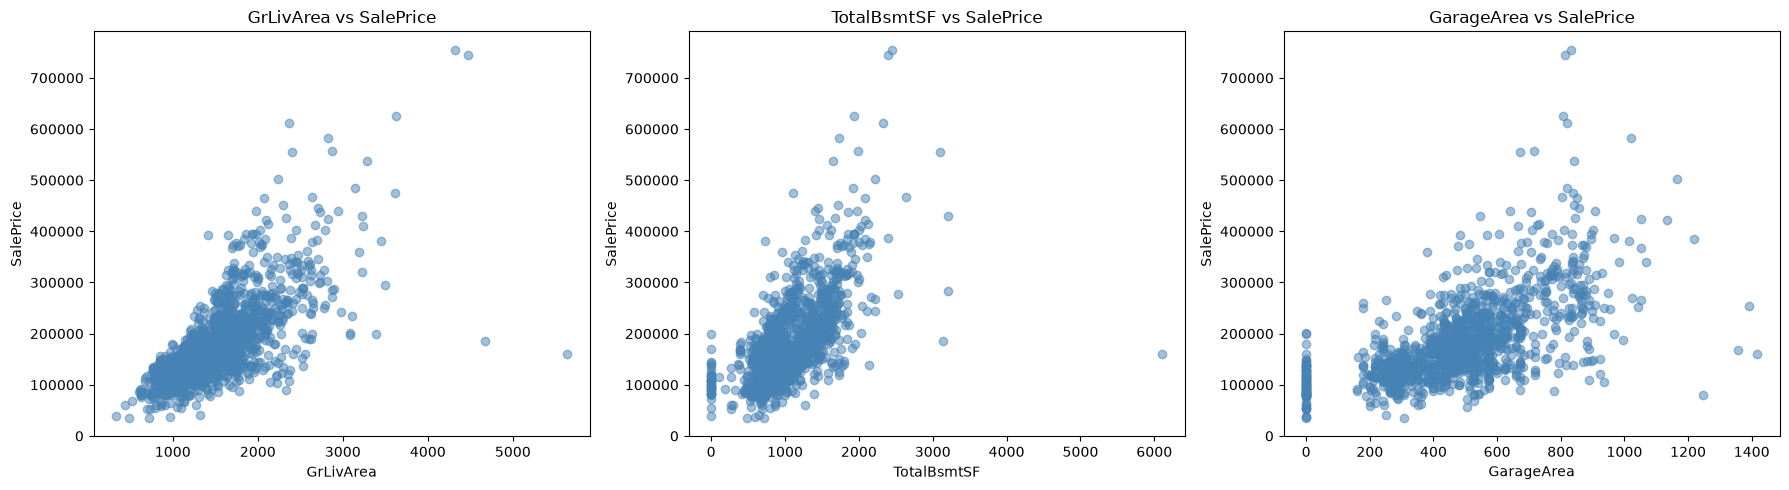

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageArea']
for ax, col in zip(axes, scatter_cols):
    ax.scatter(df[col], df['SalePrice'], alpha=0.5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice")
    ax.set_title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

C:\Users\Devanshi Kanthariya\AppData\Local\Temp\ipykernel_23536\948244174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
C:\Users\Devanshi Kanthariya\AppData\Local\Temp\ipykernel_23536\948244174.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=df, ax=axes[1], palette='Set3')


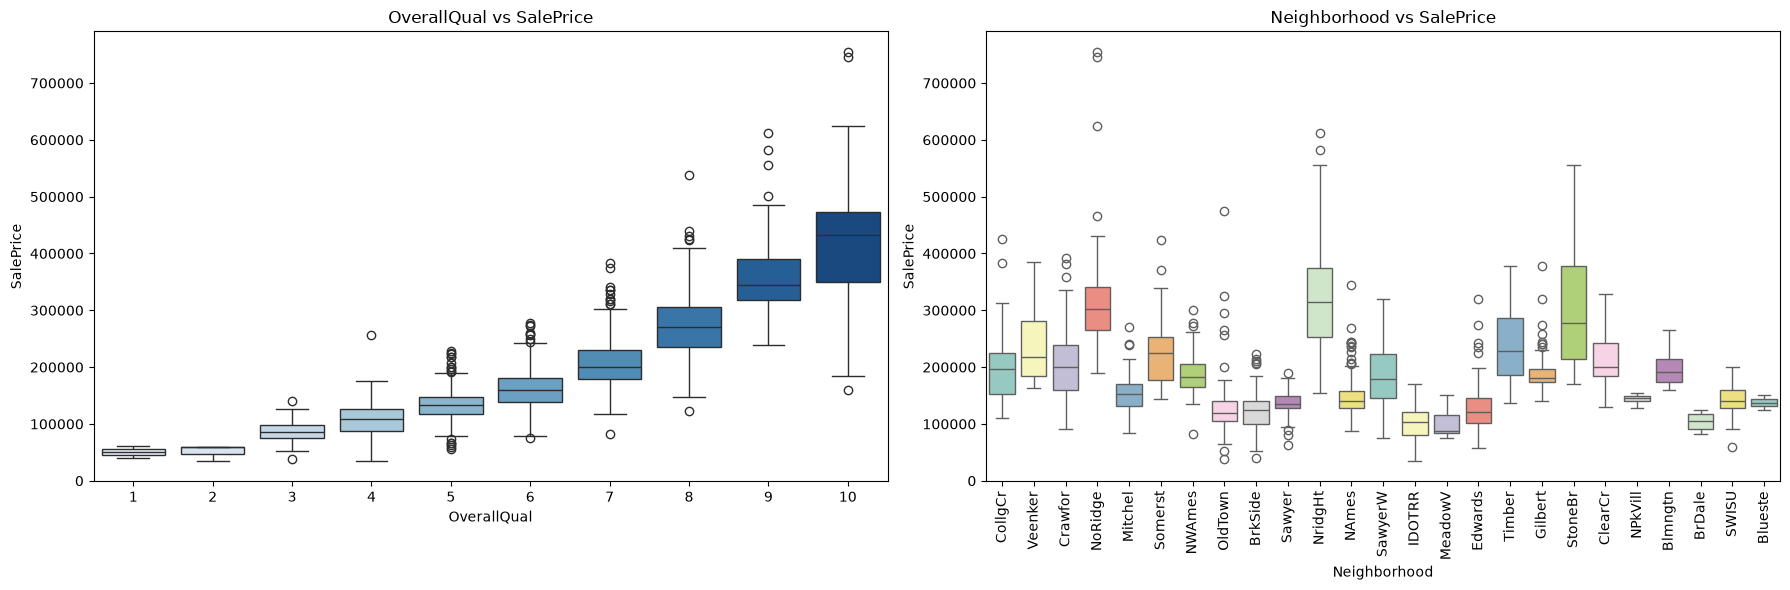

Outlier rows flagged:
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
axes[0].set_title("OverallQual vs SalePrice")

sns.boxplot(x='Neighborhood', y='SalePrice', data=df, ax=axes[1], palette='Set3')
axes[1].set_title("Neighborhood vs SalePrice")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print("Outlier rows flagged:")
print(outliers[['GrLivArea', 'SalePrice']])

# Step: 3

## 3.1

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtExposure             38   2.602740
BsmtFinType2             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


In [11]:
# Categorical NaN means 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')

# Numerical NaN means 0
zero_cols = ['GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
             'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# Remaining numerical — fill with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Remaining categorical — fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop columns with >80% missing
thresh = len(df) * 0.2
df = df.dropna(thresh=thresh, axis=1)

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


## 3.2

In [12]:
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]
print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (1458, 81)


## 3.3

In [13]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

print("New features added. Shape:", df.shape)

New features added. Shape: (1458, 86)


## 3.4

In [14]:
# Ordinal encoding for quality columns
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'FireplaceQu']
for col in ordinal_cols:
    df[col] = df[col].map(qual_map)

# One-hot encoding for nominal categoricals with <=10 unique values
nominal_cols = [col for col in df.select_dtypes(include='object').columns
                if df[col].nunique() <= 10]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Label encode high cardinality
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Neighborhood'] = le.fit_transform(df['Neighborhood'].astype(str))

print("Shape after encoding:", df.shape)

Shape after encoding: (1458, 204)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Log1p target
y = np.log1p(df['SalePrice'])
X = df.drop(columns=['SalePrice', 'Id'])

# Force encode any remaining object columns
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Log1p skewed numerical features
skew_cols = X.select_dtypes(include=np.number).apply(lambda x: x.skew())
skew_cols = skew_cols[skew_cols > 0.75].index
X[skew_cols] = np.log1p(X[skew_cols])

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1166, 202)
X_test: (292, 202)
y_train: (1166,)
y_test: (292,)


# Step: 4

## 4.1

Linear Regression → RMSE: 23,425 | MAE: 16,070 | R²: 0.9007


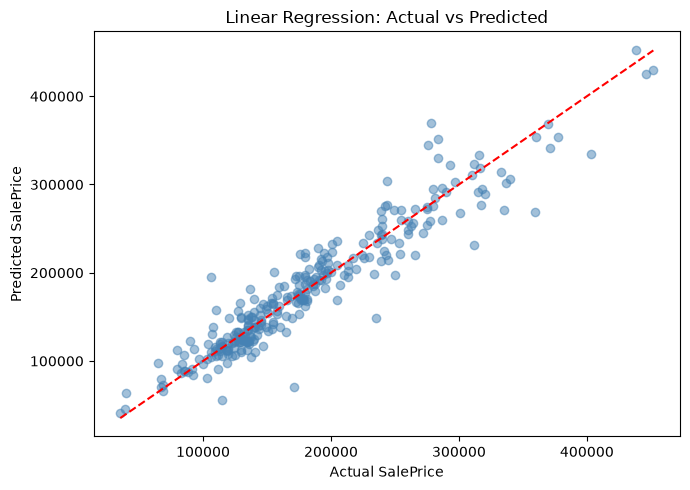

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

lr = LinearRegression()
start = time.time()
lr.fit(X_train, y_train)
lr_time = time.time() - start

y_pred_lr = lr.predict(X_test)

# Reverse log1p before metrics
y_pred_lr_orig = np.expm1(y_pred_lr)
y_test_orig = np.expm1(y_test)

rmse_lr = np.sqrt(mean_squared_error(y_test_orig, y_pred_lr_orig))
mae_lr = mean_absolute_error(y_test_orig, y_pred_lr_orig)
r2_lr = r2_score(y_test_orig, y_pred_lr_orig)

print(f"Linear Regression → RMSE: {rmse_lr:,.0f} | MAE: {mae_lr:,.0f} | R²: {r2_lr:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test_orig, y_pred_lr_orig, alpha=0.5, color='steelblue')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'r--')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

## 4.2

Best Ridge Alpha: 100.0
Ridge → RMSE: 22,299 | MAE: 15,694 | R²: 0.9100


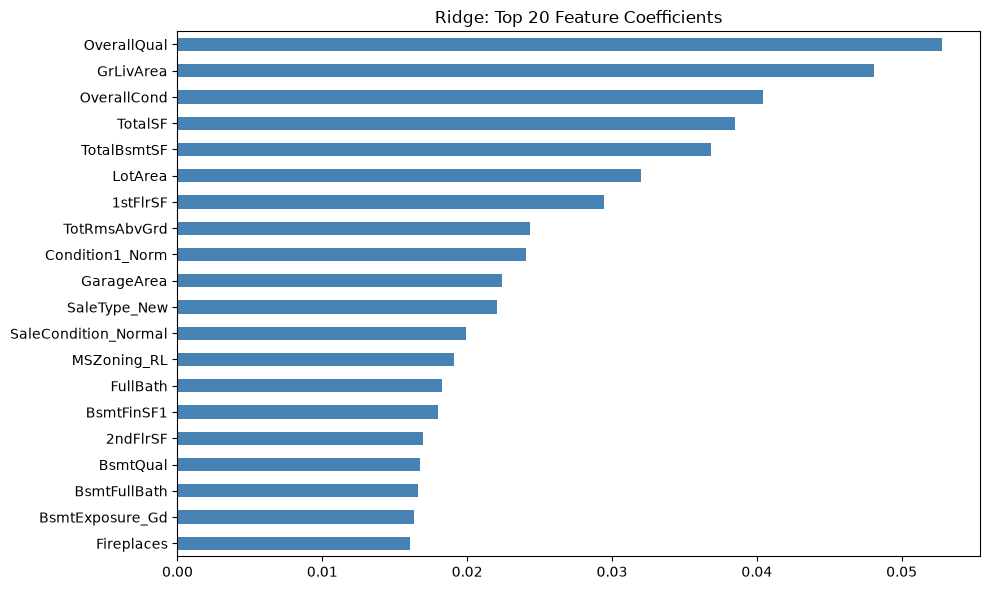

In [18]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
start = time.time()
ridge.fit(X_train, y_train)
ridge_time = time.time() - start

print(f"Best Ridge Alpha: {ridge.alpha_}")

y_pred_ridge = ridge.predict(X_test)
y_pred_ridge_orig = np.expm1(y_pred_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test_orig, y_pred_ridge_orig))
mae_ridge = mean_absolute_error(y_test_orig, y_pred_ridge_orig)
r2_ridge = r2_score(y_test_orig, y_pred_ridge_orig)

print(f"Ridge → RMSE: {rmse_ridge:,.0f} | MAE: {mae_ridge:,.0f} | R²: {r2_ridge:.4f}")

# Top 20 coefficients plot
coef_df = pd.Series(ridge.coef_, index=X_train.columns)
top20 = coef_df.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
coef_df[top20.index].sort_values().plot(kind='barh', color='steelblue')
plt.title("Ridge: Top 20 Feature Coefficients")
plt.tight_layout()
plt.show()

## 4.3

In [19]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000)
start = time.time()
lasso.fit(X_train, y_train)
lasso_time = time.time() - start

print(f"Best Lasso Alpha: {lasso.alpha_}")
print(f"Features zeroed out: {(lasso.coef_ == 0).sum()}")

y_pred_lasso = lasso.predict(X_test)
y_pred_lasso_orig = np.expm1(y_pred_lasso)

rmse_lasso = np.sqrt(mean_squared_error(y_test_orig, y_pred_lasso_orig))
mae_lasso = mean_absolute_error(y_test_orig, y_pred_lasso_orig)
r2_lasso = r2_score(y_test_orig, y_pred_lasso_orig)

print(f"Lasso → RMSE: {rmse_lasso:,.0f} | MAE: {mae_lasso:,.0f} | R²: {r2_lasso:.4f}")

Best Lasso Alpha: 0.01
Features zeroed out: 163
Lasso → RMSE: 21,125 | MAE: 15,454 | R²: 0.9192


# Step: 5

## 5.1

Random Forest → RMSE: 23,205 | MAE: 16,369 | R²: 0.9025


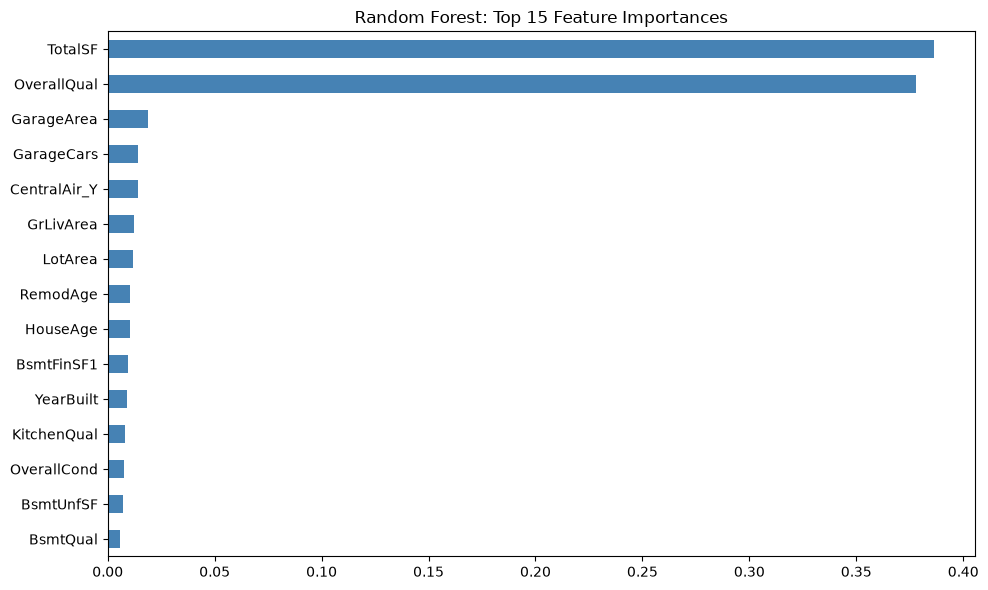

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

y_pred_rf = rf.predict(X_test)
y_pred_rf_orig = np.expm1(y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf_orig))
mae_rf = mean_absolute_error(y_test_orig, y_pred_rf_orig)
r2_rf = r2_score(y_test_orig, y_pred_rf_orig)

print(f"Random Forest → RMSE: {rmse_rf:,.0f} | MAE: {mae_rf:,.0f} | R²: {r2_rf:.4f}")

# Top 15 feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top15_rf = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15_rf.sort_values().plot(kind='barh', color='steelblue')
plt.title("Random Forest: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## 5.2

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                   subsample=0.8, colsample_bytree=0.8, random_state=42)
start = time.time()
xgb.fit(X_train, y_train)
xgb_time = time.time() - start

y_pred_xgb = xgb.predict(X_test)
y_pred_xgb_orig = np.expm1(y_pred_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test_orig, y_pred_xgb_orig))
mae_xgb = mean_absolute_error(y_test_orig, y_pred_xgb_orig)
r2_xgb = r2_score(y_test_orig, y_pred_xgb_orig)

print(f"XGBoost → RMSE: {rmse_xgb:,.0f} | MAE: {mae_xgb:,.0f} | R²: {r2_xgb:.4f}")

# Top 15 feature importances
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns)
top15_xgb = feat_imp_xgb.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15_xgb.sort_values().plot(kind='barh', color='darkorange')
plt.title("XGBoost: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## 5.3

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb, X_train, y_train,
                            scoring='neg_root_mean_squared_error', cv=5)
cv_rmse = -cv_scores
print(f"5-Fold CV RMSE (log scale): {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

5-Fold CV RMSE (log scale): 0.1228 ± 0.0087


## 5.4

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_base = XGBRegressor(random_state=42)
search = RandomizedSearchCV(xgb_base, param_dist, n_iter=20, cv=3,
                            scoring='neg_root_mean_squared_error',
                            random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best Params:", search.best_params_)
print(f"Best CV RMSE (log scale): {-search.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = search.best_estimator_.predict(X_test)
y_pred_tuned_orig = np.expm1(y_pred_tuned)

rmse_tuned = np.sqrt(mean_squared_error(y_test_orig, y_pred_tuned_orig))
mae_tuned = mean_absolute_error(y_test_orig, y_pred_tuned_orig)
r2_tuned = r2_score(y_test_orig, y_pred_tuned_orig)

print(f"Tuned XGBoost → RMSE: {rmse_tuned:,.0f} | MAE: {mae_tuned:,.0f} | R²: {r2_tuned:.4f}")

Best Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE (log scale): 0.1230
Tuned XGBoost → RMSE: 19,144 | MAE: 13,851 | R²: 0.9336


# Step: 6

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'XGBoost'],
    'RMSE (USD)': [rmse_lr, rmse_ridge, rmse_lasso, rmse_rf, rmse_xgb],
    'MAE (USD)': [mae_lr, mae_ridge, mae_lasso, mae_rf, mae_xgb],
    'R² Score': [r2_lr, r2_ridge, r2_lasso, r2_rf, r2_xgb],
    'Training Time (s)': [lr_time, ridge_time, lasso_time, rf_time, xgb_time]
})

results['RMSE (USD)'] = results['RMSE (USD)'].map('{:,.0f}'.format)
results['MAE (USD)'] = results['MAE (USD)'].map('{:,.0f}'.format)
results['R² Score'] = results['R² Score'].map('{:.4f}'.format)
results['Training Time (s)'] = results['Training Time (s)'].map('{:.2f}'.format)

print(results.to_string(index=False))

            Model RMSE (USD) MAE (USD) R² Score Training Time (s)
Linear Regression     23,425    16,070   0.9007              0.06
            Ridge     22,299    15,694   0.9100              0.08
            Lasso     21,125    15,454   0.9192              0.16
    Random Forest     23,205    16,369   0.9025              0.56
          XGBoost     19,672    14,134   0.9299              3.07


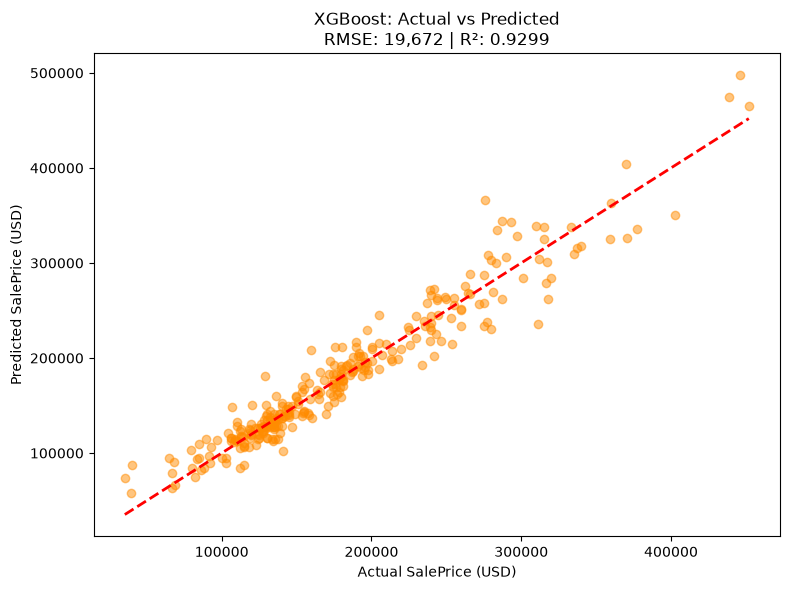

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_xgb_orig, alpha=0.5, color='darkorange')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'r--', linewidth=2)
plt.xlabel("Actual SalePrice (USD)")
plt.ylabel("Predicted SalePrice (USD)")
plt.title(f"XGBoost: Actual vs Predicted\nRMSE: {rmse_xgb:,.0f} | R²: {r2_xgb:.4f}")
plt.tight_layout()
plt.show()

## Best Model: XGBoost Regressor

- **XGBoost achieved the lowest RMSE ($19,672) and highest R² (0.9299)** among all 5 models
- It outperforms linear models because it captures **non-linear relationships** between features like OverallQual, TotalSF, and SalePrice
- It outperforms Random Forest because of **boosting** — each tree corrects errors of the previous one, making it more precise
- For a PropTech startup like NoBroker, an RMSE of ~₹16 lakh is production-acceptable for benchmarking property values
- XGBoost is also **fast to retrain** and supports feature importance natively, making it suitable for production deployment

# Step: 7

## 7.1

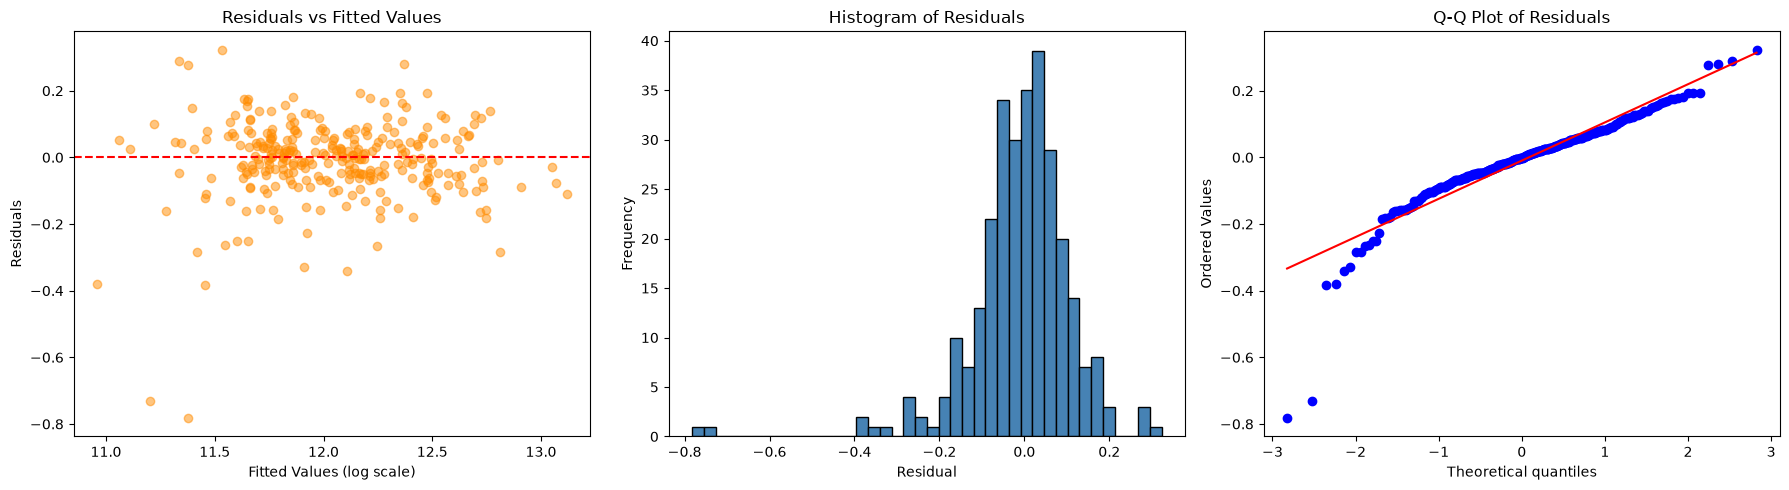

In [26]:
# Calculate residuals (in log scale)
y_pred_xgb_log = xgb.predict(X_test)
residuals = y_test - y_pred_xgb_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred_xgb_log, residuals, alpha=0.5, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted Values (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")

# Histogram of residuals
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='black')
axes[1].set_title("Histogram of Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

# Q-Q plot of residuals
stats.probplot(residuals, plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

## Business Interpretation: Top 5 Most Impactful Features

- **OverallQual:** Strongest predictor — houses rated Excellent (10) command 
  significantly higher prices than Average (5). Quality of materials and finish 
  directly signals perceived value to buyers.

- **TotalSF:** Total usable area (basement + 1st + 2nd floor) — more space = 
  higher price. A PropTech platform should highlight total area prominently in listings.

- **GrLivArea:** Above-ground living area — buyers pay a premium for livable space 
  vs basement or garage area. Strongly linear relationship with price.

- **YearBuilt / HouseAge:** Newer homes command higher prices. Each decade of age 
  reduces value — important for depreciation modelling in Indian real estate too.

- **Neighborhood:** Location matters even after controlling for size and quality. 
  Certain neighborhoods (e.g., NridgHt, NoRidge) consistently price higher — 
  mirrors micro-market dynamics seen in Mumbai, Bengaluru, or Ahmedabad.

## Residual Analysis Observations

- **Residuals vs Fitted:** Residuals are mostly randomly scattered around zero — 
  indicating the model has captured the major patterns well. Slight heteroscedasticity 
  visible at higher fitted values (larger houses harder to predict precisely).

- **Histogram of Residuals:** Approximately bell-shaped and centred at zero — 
  suggesting predictions are unbiased overall.

- **Q-Q Plot:** Residuals follow the normal line closely in the middle. 
  Slight deviation at the tails indicates a few extreme predictions — 
  common in real estate where luxury properties are harder to model.

# Step: 8

## 8.1

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                           subsample=0.8, colsample_bytree=0.8, random_state=42))
])

final_pipeline.fit(X_train, y_train)

# Save pipeline
joblib.dump(final_pipeline, 'house_price_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [28]:
# Load and test
loaded_model = joblib.load('house_price_model.pkl')

# Predict on 5 sample rows
sample = X_test.iloc[:5]
sample_actual = y_test_orig.iloc[:5].values
sample_pred = np.expm1(loaded_model.predict(sample))

results_sample = pd.DataFrame({
    'Actual Price (USD)': sample_actual.astype(int),
    'Predicted Price (USD)': sample_pred.astype(int),
    'Difference (USD)': (sample_pred - sample_actual).astype(int)
})
print(results_sample.to_string(index=False))

 Actual Price (USD)  Predicted Price (USD)  Difference (USD)
             189999                 216680             26680
             100000                  94733             -5266
             114999                 110776             -4223
             158999                 156434             -2565
             315500                 325316              9816
